In [94]:
from astropy.io import fits
import matplotlib.pyplot as plt
from astropy.wcs import WCS
import pandas as pd
from astroquery.mast import Observations
from astropy.coordinates import SkyCoord
from astropy import units
import os
import glob
import shutil

In [72]:
# path = "../data/psf_dataset/MAST_2023-08-15T0043/WFC3PSF/ibqs13lbq_11193391_F814W_flt_cutout.fits"
# path = "../data/psf_dataset/MAST_2023-08-15T0050/WFC3PSF/ibqp04v4q_22818303_F814W_flt_cutout.fits"
path = "../data/psf_dataset/MAST_2023-08-15T0058/WFC3PSF/ib7g06s6q_9597086_F606W_flc_cutout.fits"
# path = "../data/psf_dataset/MAST_2023-08-15T0102/WFC3PSF/ibqp04v1q_20665184_F814W_flc_cutout.fits"
# path = "../data/psf_dataset/MAST_2023-08-15T0109/WFC3PSF/icz907odq_10982300_F814W_flt_cutout.fits"
path = "../data/psf_dataset/MAST_2023-08-15T0111/WFC3PSF/icz907odq_10982400_F814W_flt_cutout.fits"


data = fits.open(path)
data.info()

Filename: ../data/psf_dataset/MAST_2023-08-15T0111/WFC3PSF/icz907odq_10982400_F814W_flt_cutout.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     234   (51, 51)   float32   


In [73]:
# wcs = WCS(data[0].header, data)

In [74]:
# data[0].header

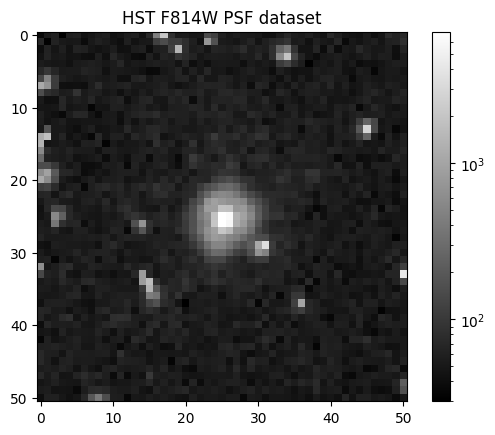

In [77]:
plt.imshow(data[0].data, cmap="gray", norm=plt.cm.colors.LogNorm())
plt.title("HST F814W PSF dataset")
plt.colorbar()

In [95]:
table = pd.read_csv("../data/psf_dataset/WFC3_PSF_UVIS_CZ9.csv", skiprows=4)
table

,id,focus,filter,psf_x_center,psf_y_center,psf_flux,qfit,exptime,aperture,rootname,...,midexp,mjd,dsn_in_wfc3_science,program_id,ra_targ,dec_targ,sunangle,fgslock,shutrpos,_selected_
0,10982300,6.10716,F814W,1610,18,67270,0.06639,1400,UVIS-CENTER,icz907odq,...,57554.21289,57554.21289,ICZ907040,CZ9,189.986205,-11.530094,109.275490,FINE,A,False
1,10982303,6.10716,F814W,2330,169,81994,0.08230,1400,UVIS-CENTER,icz907odq,...,57554.21289,57554.21289,ICZ907040,CZ9,189.986205,-11.530094,109.275490,FINE,A,False
2,10982308,6.10716,F814W,18,342,38908,0.47218,1400,UVIS-CENTER,icz907odq,...,57554.21289,57554.21289,ICZ907040,CZ9,189.986205,-11.530094,109.275490,FINE,A,False
3,10982311,6.10716,F814W,613,523,24263,0.40460,1400,UVIS-CENTER,icz907odq,...,57554.21289,57554.21289,ICZ907040,CZ9,189.986205,-11.530094,109.275490,FINE,A,False
4,10982313,6.10716,F814W,1354,680,27556,0.42002,1400,UVIS-CENTER,icz907odq,...,57554.21289,57554.21289,ICZ907040,CZ9,189.986205,-11.530094,109.275490,FINE,A,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
556,22798205,2.10884,F814W,2947,1480,63730,0.02850,1400,UVIS-CENTER,icz906e8q,...,57552.64063,57552.64063,ICZ906040,CZ9,189.986205,-11.530094,110.765564,FINE,B,False
557,22798206,2.10884,F814W,1566,1734,23137,0.49415,1400,UVIS-CENTER,icz906e8q,...,57552.64063,57552.64063,ICZ906040,CZ9,189.986205,-11.530094,110.765564,FINE,B,False
558,22798207,2.10884,F814W,3446,1777,22228,0.47658,1400,UVIS-CENTER,icz906e8q,...,57552.64063,57552.64063,ICZ906040,CZ9,189.986205,-11.530094,110.765564,FINE,B,False
559,22798208,2.10884,F814W,678,1992,85548,0.03421,1400,UVIS-CENTER,icz906e8q,...,57552.64063,57552.64063,ICZ906040,CZ9,189.986205,-11.530094,110.765564,FINE,B,False


In [103]:
coord = SkyCoord("12:39:56.689", "-11:31:48.34", unit=(units.hourangle, units.deg))
# Query the object
obs_table = Observations.query_criteria(project="HST", s_ra=coord.ra.value, s_dec=coord.dec.value)
obs_table

intentType,obs_collection,provenance_name,instrument_name,project,filters,wavelength_region,target_name,target_classification,obs_id,s_ra,s_dec,dataproduct_type,proposal_pi,calib_level,t_min,t_max,t_exptime,em_min,em_max,obs_title,t_obs_release,proposal_id,proposal_type,sequence_number,s_region,jpegURL,dataURL,dataRights,mtFlag,srcDen,obsid,objID
str11,str3,str6,str11,str3,str15,str8,str29,str38,str9,float64,float64,str10,str27,int64,float64,float64,float64,float64,float64,str146,float64,str5,str8,int64,str6213,str34,str35,str6,bool,float64,str8,str9
science,HST,CALNIC,NICMOS/NIC1,HST,F160W,Infrared,HD106965,CALIBRATION;PHOTOMETRIC,n3xd03cpq,184.476199111,1.572130677273,image,"MacKenty, John W.",2,50564.73811767361,50564.739969525464,159.8567,1408.3999999999999,1809.4,NICMOS Persistence Test,50565.53700225,7045,SM2/NIC,--,POLYGON 184.477183 1.574057 184.478127 1.571129 184.475208 1.570189 184.474264 1.573117 184.477183 1.574057,mast:HST/product/n3xd03cpq_cal.jpg,mast:HST/product/n3xd03cpq_cal.fits,PUBLIC,False,nan,24158909,124894197
science,HST,CALNIC,NICMOS/NIC1,HST,F160W,Infrared,HD106965,CALIBRATION;PHOTOMETRIC,n3xd02zjq,184.4987460875,1.577625166463,image,"MacKenty, John W.",2,50563.93153202546,50563.93748599537,514.386,1408.3999999999999,1809.4,NICMOS Persistence Test,50564.72108792,7045,SM2/NIC,--,POLYGON 184.499871 1.579473 184.500593 1.576482 184.497612 1.575763 184.49689 1.578754 184.499871 1.579473,mast:HST/product/n3xd02zjq_cal.jpg,mast:HST/product/n3xd02zjq_cal.fits,PUBLIC,False,nan,24158899,124894210
calibration,HST,CALNIC,NICMOS/NIC2,HST,BLANK,--,DARK,--,n3xd02zoq,184.4896161065,1.575199334464,image,"MacKenty, John W.",2,50563.93773568287,50563.94368966435,514.386,nan,nan,NICMOS Persistence Test,50564.72039342,7045,SM2/NIC,--,POLYGON 184.49154 1.578473 184.492879 1.573226 184.487677 1.5719 184.486338 1.577147 184.49154 1.578473,mast:HST/product/n3xd02zoq_cal.jpg,mast:HST/product/n3xd02zoq_cal.fits,PUBLIC,False,nan,24158901,124894221
science,HST,CALNIC,NICMOS/NIC3,HST,F222M,Infrared,ANTSU,CALIBRATION;INSTRUMENT SENSITIVI,n3xfa1030,225.0001078622,-19.99976104446,image,"Calzetti, Daniela",3,50565.48780093,50565.51064815,1024.0,2145.7000000000003,2291.1,NICMOS POINTED THERMAL BACKGROUND TEST,50565.708912,7047,SM2/NIC,--,POLYGON -135.00553000000002 -20.00945 -135.004792084549 -20.009250723520445 -135.004792 -20.009251 -134.99515738380228 -20.006648860174753 -134.99028499999997 -20.005333 -134.9902850892199 -20.005332708313826 -134.989916 -20.005233 -134.98991601289563 -20.005232957840665 -134.98954600000002 -20.005133 -134.99219874263056 -19.996461925012422 -134.994164 -19.990036 -134.99536850602485 -19.990361412128646 -135.009408 -19.994153 -135.00940797207377 -19.99415309133725 -135.00977799999998 -19.994253 -135.00977789770866 -19.99425333456044 -135.01014699999996 -19.994353 -135.01004091228077 -19.994699976315523 -135.010041 -19.9947 -135.00993491228093 -19.995046976315834 -135.00993500000004 -19.995047 -135.00982888948093 -19.995393970159697 -135.00982899999997 -19.995394 -135.00897679904125 -19.99818056192564 -135.005743 -20.008756 -135.00574233244447 -20.008755819725948 -135.00553000000002 -20.00945 -135.00553000000002 -20.00945,mast:HST/product/n3xfa1030_mos.jpg,mast:HST/product/n3xfa1030_mos.fits,PUBLIC,False,nan,24847744,124894237
science,HST,CALNIC,NICMOS/NIC3,HST,F175W,Infrared,P035-R,STAR;M V-IV,n3xe03050,126.4312805421,73.01920531553,image,"Calzetti, Daniela",3,50567.1462037,50567.149587465276,40.0,1359.55,2334.65,NICMOS Grism Validation,50567.69560176,7055,SM2/NIC,--,POLYGON 126.434367 73.031872 126.42562551209274 73.029671826712928 126.425625 73.029672 126.387912 73.020169 126.41120040088944 73.0122892803752 126.428155 73.006546 126.46586 73.016042 126.46585972652798 73.0160420927377 126.474601 73.018241 126.46707196020498 73.02079398999075 126.467072 73.020794 126.434367 73.031872 126.434367 73.031872,mast:HST/product/n3xe03050_mos.jpg,mast:HST/product/n3xe03050_mos.fits,PUBLIC,False,nan,24847733,124